# RM (Reissner-Mindlin) Timoshenko 6×6 from a 1-D shell YAML

The **Reissner-Mindlin (RM) shell** cross-section model carries an independent through-thickness
*director rotation*, so it retains the **transverse-shear** compliance that the Kirchhoff-Love model
discards. For thin-walled composite sections the payoff is the two shear-stiffness terms
$GA_{2}$ and $GA_{3}$ (rows/cols 2,3 of the $6\times6$).

This tutorial runs the RM solver on the **single-ply $[-45]$ tube** (thesis §3.1.4) directly from its
1-D shell SG YAML, draws the $e_1/e_2/e_3$ material orientation, and benchmarks the result against the
2-D solid reference. The Timoshenko stiffness order is
$[\,EA,\;GA_2,\;GA_3,\;GJ,\;EI_2,\;EI_3\,]$.

> Driver: `strip_RM.rm_timoshenko_6x6(yaml, frac, dshift, curved, shear="mitc")`
> (`shear="mitc"` = selective assumed-strain transverse shear).

In [1]:
import os, sys, time
import numpy as np
def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent
CC = _find_repo_root()
for p in ("", "opensg_jax"):
    sys.path.insert(0, os.path.join(CC, p))
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=150, suppress=True)
from IPython.display import Image
from fe_jax.orient_plot import plot_orient
from opensg_jax.fe_jax.timo_report import (sym, pcterr, full_pcterr, diag_table, term_table,
                                          compare_terms, print_6x6, nonzero_terms, parse_vabs, wall_t, LBL)
print("environment ready  |  jax", jax.__version__)

environment ready  |  jax 0.9.2


In [2]:
SHELL = os.path.join(CC, "examples", "data", "1d_yaml", "tube_m45_shell.yaml")
SOLIDY = os.path.join(CC, "examples", "data", "2d_yaml", "tube_m45_solid.yaml")
BENCH = os.path.join(CC, "examples", "data", "benchmark", "tube_m45_solid_ref.txt")   # 2-D solid reference 6x6
print("shell YAML :", os.path.basename(SHELL))
print("solid YAML :", os.path.basename(SOLIDY))
print("benchmark  :", os.path.basename(BENCH))

shell YAML : tube_m45_shell.yaml
solid YAML : tube_m45_solid.yaml
benchmark  : tube_m45_solid_ref.txt


## Material orientation ($e_1$ beam axis, $e_2$ tangent, $e_3$ wall normal)

$e_2$ (blue) is the in-plane ply-flow direction, $e_3$ (green when OML→IML) is the wall normal, and
$e_1$ is the out-of-plane beam axis ($e_{1z}\approx1$).

[orient_plot] SHELL: e3 OML->IML 200/200   e1_z mean=1.000


[orient_plot] SOLID: e3 OML->IML 464/464   e1_z mean=0.707


[orient_plot] wrote _img/rm_tube_orient.png


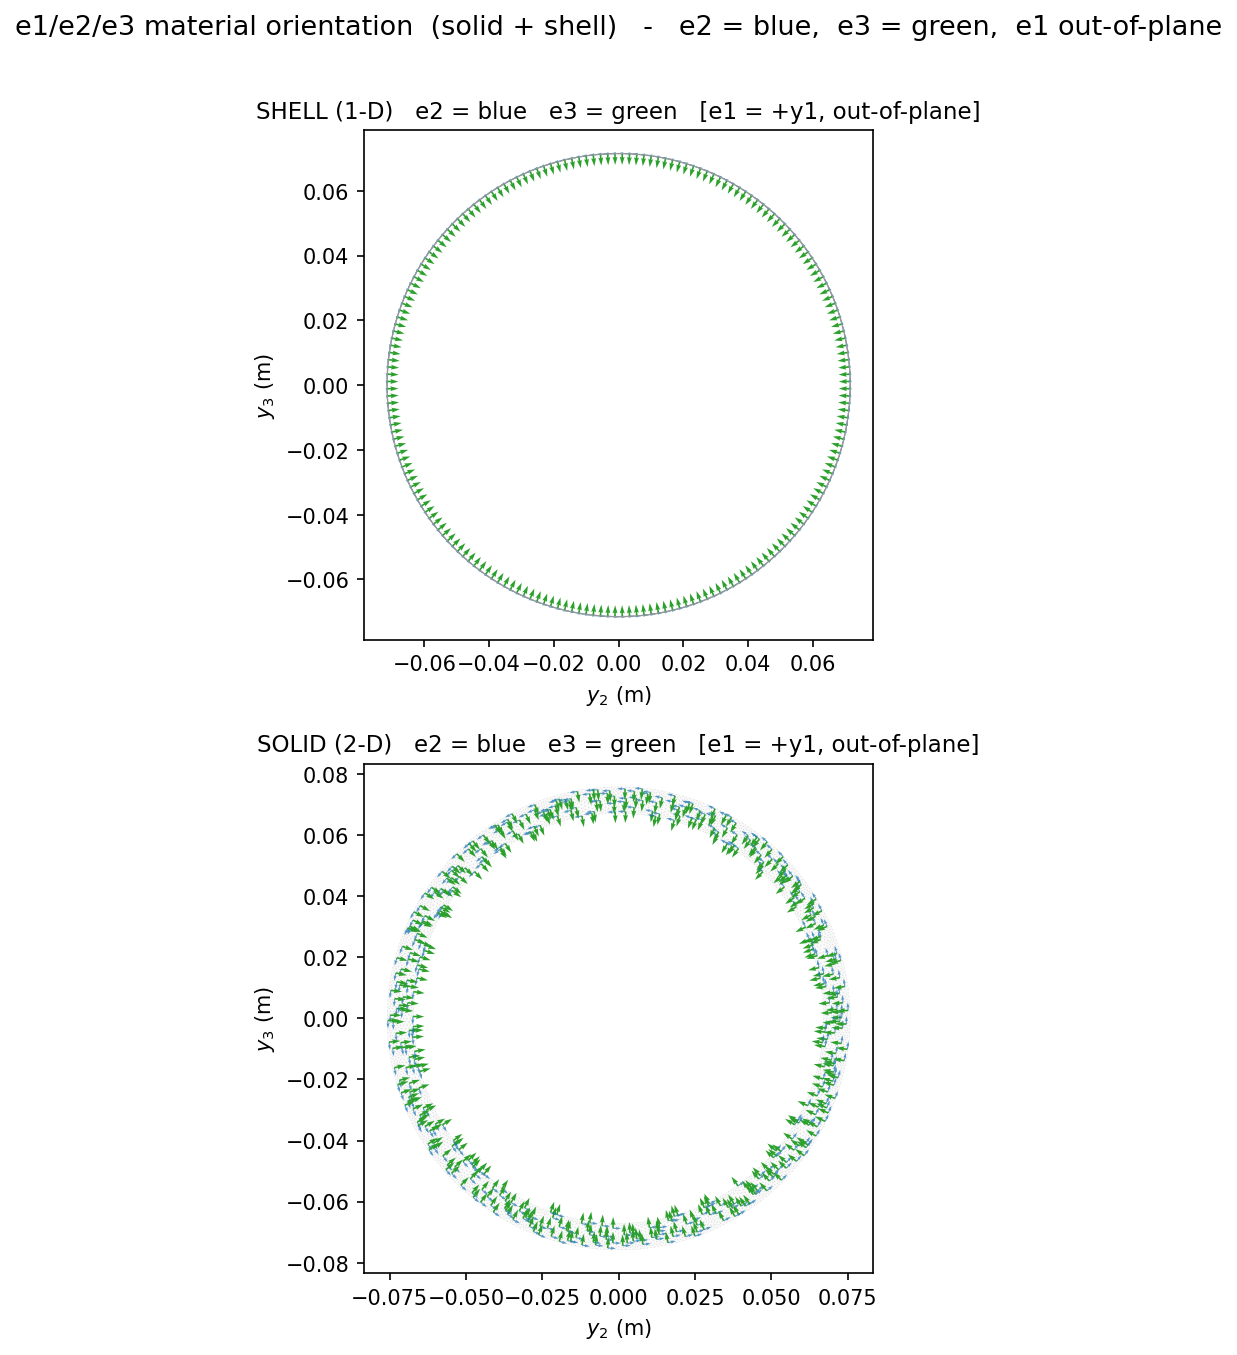

In [3]:
png = plot_orient(SHELL, SOLIDY, out_png=os.path.join(os.path.join(CC, "docs", "tutorials", "_img"), "rm_tube_orient.png"))
Image(filename=png)

## Compute the RM Timoshenko 6×6

In [4]:
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
t0 = time.time()
C_rm = sym(rm_timoshenko_6x6(SHELL, 0.0, dshift=None, curved=True, shear="mitc"))
print("RM solve: %.2f s\n" % (time.time() - t0))
print("RM Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:")
print(C_rm)

[orient_plot] SHELL: e3 OML->IML 200/200   e1_z mean=1.000


[orient_plot] wrote ../../examples/data/1d_yaml/tube_m45_shell_orient_e1e2e3.png


RM solve: 3.96 s

RM Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:
[[47727163.5222        0.           -0.      -822254.2231       -0.           -0.    ]
 [       0.     12765019.6053        0.            0.       410964.0669       -0.    ]
 [      -0.            0.     12765019.6053        0.            0.       410964.0669]
 [ -822254.2231        0.            0.       115573.6873        0.           -0.    ]
 [      -0.       410964.0669        0.            0.       107699.363        -0.    ]
 [      -0.           -0.       410964.0669       -0.           -0.       107699.363 ]]


## Benchmark vs the 2-D solid, and vs Kirchhoff-Love

KL severely under-predicts $GA_2,GA_3$; RM recovers them.

In [5]:
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
S = sym(np.loadtxt(BENCH))                                  # 2-D solid reference 6x6
C_kl = sym(gradient_junction_kirchhoff(SHELL, frac=0.0, dshift=None)[0])
print_6x6(C_kl, "KL (1-D shell)")
print("\nRM and KL vs the 2-D solid - every non-zero Cij term (RM recovers the shear couplings KL loses):")
compare_terms(S, {"RM": C_rm, "KL": C_kl})

KL (1-D shell) Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:
    4.77526e+07   9.97823e+03  -5.49920e+03  -8.20792e+05   3.36665e+02  -1.96780e+02
    9.97823e+03   8.13997e+06  -4.67555e+06  -5.07957e+02   2.60702e+05  -1.53256e+05
   -5.49920e+03  -4.67555e+06   4.59439e+06   3.11851e+02  -1.49309e+05   1.49713e+05
   -8.20792e+05  -5.07957e+02   3.11851e+02   1.15362e+05  -1.71307e+01   1.10482e+01
    3.36665e+02   2.60702e+05  -1.49309e+05  -1.71307e+01   1.02814e+05  -4.89373e+03
   -1.96780e+02  -1.53256e+05   1.49713e+05   1.10482e+01  -4.89373e+03   9.93426e+04

RM and KL vs the 2-D solid - every non-zero Cij term (RM recovers the shear couplings KL loses):
  term             solid/ref             RM      RM%d             KL      KL%d
  C11(EA)         4.7738e+07     4.7727e+07    -0.02     4.7753e+07    +0.03
  C14            -9.3912e+05    -8.2225e+05   -12.44    -8.2079e+05   -12.60
  C22(GA2)        1.4661e+07     1.2765e+07   -12.93     8.1400e+06   -44.48
  C25          

{'RM': np.float64(22.607251328921194), 'KL': np.float64(68.66167848106944)}

## Takeaway

On the $[-45]$ tube the **shear terms** separate the models: KL gives $GA_2,GA_3$ errors of
$\sim-44\%/-69\%$, while **RM** brings them to $\sim-13\%$. Classical terms already agree to under 1%.
For the full 2-D solid reference (matched to VABS) see the **JAX-solid** tutorial.